In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Installing the Kaggle API client to download datset

In [ ]:
#!pip install kaggle

In [ ]:
import os
from google.colab import files

# Create a directory for Kaggle
!mkdir -p ~/.kaggle

# Upload kaggle.json
files.upload()

# Move the uploaded file to the Kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key uploaded and configured successfully!")

Saving kaggle.json to kaggle.json
Kaggle API key uploaded and configured successfully!


In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:10<00:00, 204MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
dataset_path = "data/plantvillage dataset/color"

# Making the dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
train_data = datagen.flow_from_directory(
    "data/plantvillage dataset/color",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 43456 images belonging to 38 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    "data/plantvillage dataset/color",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 10849 images belonging to 38 classes.


<Figure size 640x480 with 0 Axes>

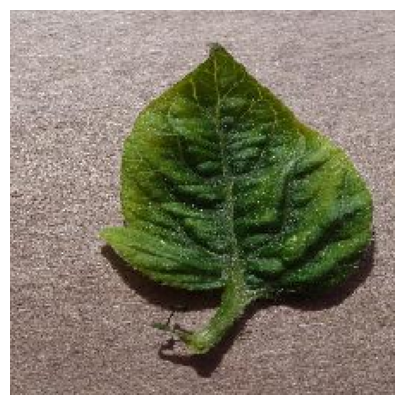

In [ ]:
images, labels = next(train_data)

plt.clf()
plt.figure(figsize=(5,5))   # create fresh figure
plt.imshow(images[0])
plt.axis('off')
plt.show()

In [ ]:
images, labels = next(train_data)
labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.], dtype=float32)

In [ ]:
class_indices = train_data.class_indices

In [ ]:
class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___Powdery_mildew': 5,
 'Cherry_(including_sour)___healthy': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___Northern_Leaf_Blight': 9,
 'Corn_(maize)___healthy': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13,
 'Grape___healthy': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___Late_blight': 21,
 'Potato___healthy': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___Leaf_scorch': 26,
 'Strawberry___healthy': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [ ]:
index_to_class = {v:k for k,v in class_indices.items()}

In [ ]:
index_to_class

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
label_index = np.argmax(labels[0])
print(index_to_class[label_index])

Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [ ]:
print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 38)


# CNN Model

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,912,294 (91.22 MB)

 Trainable params: 23,912,294 (91.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3
)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 90s 63ms/step - accuracy: 0.7004 - loss: 1.0591 - val_accuracy: 0.8289 - val_loss: 0.5448
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step - accuracy: 0.8872 - loss: 0.3576 - val_accuracy: 0.8671 - val_loss: 0.4340
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9476 - loss: 0.1613 - val_accuracy: 0.8495 - val_loss: 0.5624


In [ ]:
# Display the full training history
print("Training History (Epochs, Accuracy, Loss):")
print(pd.DataFrame(history.history))

# Get the last epoch's values
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Training History (Epochs, Accuracy, Loss):
   accuracy      loss  val_accuracy  val_loss
0  0.700364  1.059100      0.828924  0.544784
1  0.887242  0.357593      0.867085  0.434040
2  0.947556  0.161309      0.849479  0.562389

Final Training Accuracy: 0.9476
Final Validation Accuracy: 0.8495
Final Training Loss: 0.1613
Final Validation Loss: 0.5624


In [ ]:
model.save("plant_disease_model.h5")

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("plant_disease_model.h5")

In [ ]:
images, labels = next(val_data)

preds = model.predict(images)

for i in range(5):
    pred_class = np.argmax(preds[i])
    true_class = np.argmax(labels[i])

    print("Pred:", index_to_class[pred_class])
    print("True:", index_to_class[true_class])
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Pred: Apple___Apple_scab
True: Apple___Apple_scab
------
Pred: Orange___Haunglongbing_(Citrus_greening)
True: Orange___Haunglongbing_(Citrus_greening)
------
Pred: Tomato___Tomato_Yellow_Leaf_Curl_Virus
True: Tomato___Tomato_Yellow_Leaf_Curl_Virus
------
Pred: Orange___Haunglongbing_(Citrus_greening)
True: Orange___Haunglongbing_(Citrus_greening)
------
Pred: Corn_(maize)___healthy
True: Corn_(maize)___healthy
------


In [ ]:
loss, accuracy = model.evaluate(val_data)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.8568 - loss: 0.5072
Validation Loss: 0.5072
Validation Accuracy: 0.8568


Model is overfit , using data augmentation to fix it

In [ ]:
datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data_aug = datagen_aug.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 43456 images belonging to 38 classes.


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data_aug = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 10849 images belonging to 38 classes.


In [ ]:
Augmented_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), #added dropout to reduce overfitting
    layers.Dense(train_data_aug.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
Augmented_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_aug = Augmented_model.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=5
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 545s 399ms/step - accuracy: 0.3567 - loss: 2.3655 - val_accuracy: 0.6031 - val_loss: 1.3308
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 548s 404ms/step - accuracy: 0.5157 - loss: 1.6521 - val_accuracy: 0.6260 - val_loss: 1.2297
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 540s 398ms/step - accuracy: 0.5655 - loss: 1.4586 - val_accuracy: 0.6917 - val_loss: 0.9828
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 565s 400ms/step - accuracy: 0.5929 - loss: 1.3421 - val_accuracy: 0.7486 - val_loss: 0.8006
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 545s 402ms/step - accuracy: 0.6153 - loss: 1.2664 - val_accuracy: 0.7742 - val_loss: 0.7164


In [ ]:
# Display the full training history for the augmented model
print("Training History (Epochs, Accuracy, Loss) for Augmented Model:")
print(pd.DataFrame(history_aug.history))

# Get the last epoch's values for the augmented model
final_train_acc_aug = history_aug.history['accuracy'][-1]
final_val_acc_aug = history_aug.history['val_accuracy'][-1]
final_train_loss_aug = history_aug.history['loss'][-1]
final_val_loss_aug = history_aug.history['val_loss'][-1]

print(f"\nFinal Augmented Training Accuracy: {final_train_acc_aug:.4f}")
print(f"Final Augmented Validation Accuracy: {final_val_acc_aug:.4f}")
print(f"Final Augmented Training Loss: {final_train_loss_aug:.4f}")
print(f"Final Augmented Validation Loss: {final_val_loss_aug:.4f}")

Training History (Epochs, Accuracy, Loss) for Augmented Model:
   accuracy      loss  val_accuracy  val_loss
0  0.356729  2.365507      0.603097  1.330774
1  0.515740  1.652106      0.625956  1.229694
2  0.565515  1.458646      0.691677  0.982777
3  0.592945  1.342125      0.748640  0.800576
4  0.615312  1.266444      0.774173  0.716400

Final Augmented Training Accuracy: 0.6153
Final Augmented Validation Accuracy: 0.7742
Final Augmented Training Loss: 1.2664
Final Augmented Validation Loss: 0.7164


In [ ]:
Augmented_model.save('Plant_Disease_Augmented_model.h5')

In [ ]:
from tensorflow.keras.models import load_model
Augmented_model = load_model('Plant_Disease_Augmented_model.h5')

# Transfer Learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
tl_base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# feature extraction

In [ ]:
tl_base_model.trainable = False

In [ ]:
tl_base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
TL_model = models.Sequential([
    tl_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
    ])

In [ ]:
TL_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
TL_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_tl = TL_model.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=3)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 581s 413ms/step - accuracy: 0.7179 - loss: 0.9745 - val_accuracy: 0.9007 - val_loss: 0.3114
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 535s 393ms/step - accuracy: 0.8337 - loss: 0.5248 - val_accuracy: 0.9150 - val_loss: 0.2576
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 521s 384ms/step - accuracy: 0.8542 - loss: 0.4481 - val_accuracy: 0.9210 - val_loss: 0.2393


In [ ]:
# Display the full training history for the transfer learning model
print("Training History (Epochs, Accuracy, Loss) for Transfer Learning Model:")
print(pd.DataFrame(history_tl.history))

# Get the last epoch's values for the transfer learning model
final_train_acc_tl = history_tl.history['accuracy'][-1]
final_val_acc_tl = history_tl.history['val_accuracy'][-1]
final_train_loss_tl = history_tl.history['loss'][-1]
final_val_loss_tl = history_tl.history['val_loss'][-1]

print(f"\nFinal Transfer Learning Training Accuracy: {final_train_acc_tl:.4f}")
print(f"Final Transfer Learning Validation Accuracy: {final_val_acc_tl:.4f}")
print(f"Final Transfer Learning Training Loss: {final_train_loss_tl:.4f}")
print(f"Final Transfer Learning Validation Loss: {final_val_loss_tl:.4f}")

Training History (Epochs, Accuracy, Loss) for Transfer Learning Model:
   accuracy      loss  val_accuracy  val_loss
0  0.717853  0.974506      0.900728  0.311368
1  0.833671  0.524824      0.915015  0.257620
2  0.854197  0.448053      0.921007  0.239298

Final Transfer Learning Training Accuracy: 0.8542
Final Transfer Learning Validation Accuracy: 0.9210
Final Transfer Learning Training Loss: 0.4481
Final Transfer Learning Validation Loss: 0.2393


In [ ]:
TL_model.save('Plant_Disease_TL_model.h5')

# fine tuning

In [ ]:
tl_base_model.trainable = True

In [ ]:
for layer in tl_base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

TL_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_FT = TL_model.fit(
    train_data_aug,
    validation_data=val_data_aug,
    epochs=3
)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 547s 390ms/step - accuracy: 0.8727 - loss: 0.4132 - val_accuracy: 0.9344 - val_loss: 0.2123
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 522s 384ms/step - accuracy: 0.9254 - loss: 0.2360 - val_accuracy: 0.9602 - val_loss: 0.1230
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 523s 385ms/step - accuracy: 0.9446 - loss: 0.1756 - val_accuracy: 0.9650 - val_loss: 0.1044


In [ ]:
TL_model.save('Plant_Disease_FT_model.h5')

In [ ]:
# Get the last epoch's values for the fine-tuned transfer learning model
final_train_acc_ft = history_FT.history['accuracy'][-1]
final_val_acc_ft = history_FT.history['val_accuracy'][-1]
final_train_loss_ft = history_FT.history['loss'][-1]
final_val_loss_ft = history_FT.history['val_loss'][-1]

print(f"Final Fine-tuned Training Accuracy: {final_train_acc_ft:.4f}")
print(f"Final Fine-tuned Validation Accuracy: {final_val_acc_ft:.4f}")
print(f"Final Fine-tuned Training Loss: {final_train_loss_ft:.4f}")
print(f"Final Fine-tuned Validation Loss: {final_val_loss_ft:.4f}")

Final Fine-tuned Training Accuracy: 0.9446
Final Fine-tuned Validation Accuracy: 0.9650
Final Fine-tuned Training Loss: 0.1756
Final Fine-tuned Validation Loss: 0.1044


### Visualizing Final Validation Accuracy and Loss for All Models

### Recalculating Validation Metrics for All Models

In [ ]:
from tensorflow.keras.models import load_model

# Recalculate metrics for Initial CNN Model
initial_cnn_model = load_model("plant_disease_model.h5")
loss_initial_cnn, acc_initial_cnn = initial_cnn_model.evaluate(val_data, verbose=0)
final_val_acc = acc_initial_cnn
final_val_loss = loss_initial_cnn
print(f"Initial CNN - Val Accuracy: {final_val_acc:.4f}, Val Loss: {final_val_loss:.4f}")

# Recalculate metrics for Augmented CNN Model
augmented_cnn_model = load_model("Plant_Disease_Augmented_model.h5")
loss_aug_cnn, acc_aug_cnn = augmented_cnn_model.evaluate(val_data_aug, verbose=0)
final_val_acc_aug = acc_aug_cnn
final_val_loss_aug = loss_aug_cnn
print(f"Augmented CNN - Val Accuracy: {final_val_acc_aug:.4f}, Val Loss: {final_val_loss_aug:.4f}")

# Recalculate metrics for Transfer Learning (Feature Extraction) Model
tl_fe_model = load_model("Plant_Disease_TL_model.h5")
loss_tl_fe, acc_tl_fe = tl_fe_model.evaluate(val_data_aug, verbose=0)
final_val_acc_tl = acc_tl_fe
final_val_loss_tl = loss_tl_fe
print(f"TL (Feature Extraction) - Val Accuracy: {final_val_acc_tl:.4f}, Val Loss: {final_val_loss_tl:.4f}")

# Recalculate metrics for Transfer Learning (Fine-tuned) Model
tl_ft_model = load_model("Plant_Disease_FT_model.h5")
loss_tl_ft, acc_tl_ft = tl_ft_model.evaluate(val_data_aug, verbose=0)
final_val_acc_ft = acc_tl_ft
final_val_loss_ft = loss_tl_ft
print(f"TL (Fine-tuned) - Val Accuracy: {final_val_acc_ft:.4f}, Val Loss: {final_val_loss_ft:.4f}")

Initial CNN - Val Accuracy: 0.8568, Val Loss: 0.5072


Augmented CNN - Val Accuracy: 0.7742, Val Loss: 0.7164


TL (Feature Extraction) - Val Accuracy: 0.9210, Val Loss: 0.2393


TL (Fine-tuned) - Val Accuracy: 0.9650, Val Loss: 0.1044


### Visualizing Final Validation Accuracy and Loss for All Models

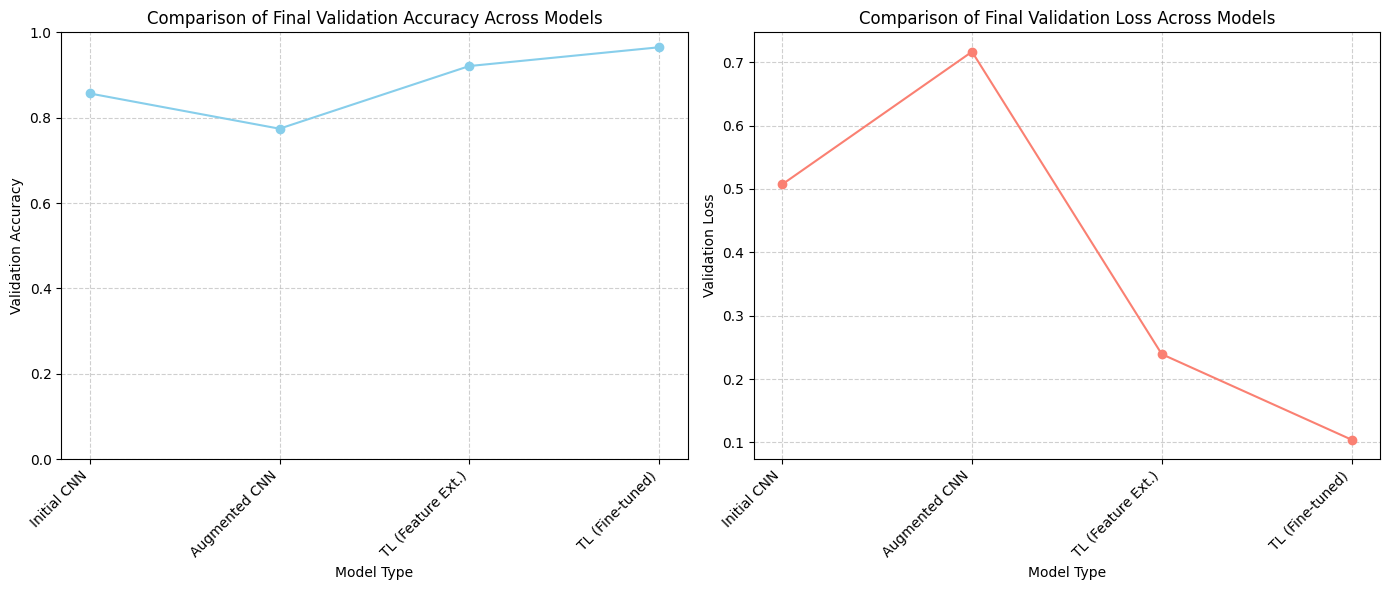

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Model names for the x-axis
model_names = [
    'Initial CNN',
    'Augmented CNN',
    'TL (Feature Ext.)',
    'TL (Fine-tuned)'
]

# Collect final validation accuracies
validation_accuracies = [
    final_val_acc,
    final_val_acc_aug,
    final_val_acc_tl,
    final_val_acc_ft
]

# Collect final validation losses
validation_losses = [
    final_val_loss,
    final_val_loss_aug,
    final_val_loss_tl,
    final_val_loss_ft
]

plt.figure(figsize=(14, 6))

# Plot Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(model_names, validation_accuracies, marker='o', linestyle='-', color='skyblue')
plt.title('Comparison of Final Validation Accuracy Across Models')
plt.xlabel('Model Type')
plt.ylabel('Validation Accuracy')
plt.ylim(0.0, 1.0) # Accuracy ranges from 0 to 1
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')

# Plot Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(model_names, validation_losses, marker='o', linestyle='-', color='salmon')
plt.title('Comparison of Final Validation Loss Across Models')
plt.xlabel('Model Type')
plt.ylabel('Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Prediction Pipeline

In [3]:
from tensorflow.keras.models import load_model
final_model = load_model("Plant_Disease_FT_model.h5")

In [10]:
import json

with open("Plant_class_mappings.json", "w") as f:
    json.dump(index_to_class, f)

In [12]:
with open("Plant_class_mappings.json", "r") as f:
    index_to_class = json.load(f)

index_to_class = {int(k): v for k, v in index_to_class.items()}

In [4]:
from tensorflow.keras.preprocessing import image

In [14]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array/255.0
    img_array = np.expand_dims(img_array,axis=0)

    return img_array

In [15]:
def predict_image(img_path):
  img = preprocess_image(img_path)

  pred = final_model.predict(img)
  pred_class = np.argmax(pred)

  class_name = index_to_class[pred_class]
  confidence = pred[0][pred_class]

  return class_name, confidence

In [33]:
disease_info = {
    "Apple___Apple_scab": "A fungal disease causing dark, scabby lesions on leaves and fruit.",
    "Apple___Black_rot": "Fungal disease causing black rot on fruits and leaf spots.",
    "Apple___Cedar_apple_rust": "Causes orange spots on leaves due to fungal infection.",
    "Apple___healthy": "The plant is healthy with no visible disease.",

    "Blueberry___healthy": "The plant is healthy with no visible disease.",

    "Cherry_(including_sour)___Powdery_mildew": "Fungal disease causing white powdery growth on leaves.",
    "Cherry_(including_sour)___healthy": "The plant is healthy with no visible disease.",

    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "Causes gray lesions on leaves, reducing yield.",
    "Corn_(maize)___Common_rust_": "Produces reddish-brown pustules on leaves.",
    "Corn_(maize)___Northern_Leaf_Blight": "Causes long gray-green lesions on leaves.",
    "Corn_(maize)___healthy": "The plant is healthy with no visible disease.",

    "Grape___Black_rot": "Causes black spots on leaves and shriveled fruits.",
    "Grape___Esca_(Black_Measles)": "Fungal disease causing dark spots and leaf discoloration.",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Causes brown lesions on leaves.",
    "Grape___healthy": "The plant is healthy with no visible disease.",

    "Orange___Haunglongbing_(Citrus_greening)": "A bacterial disease causing yellowing leaves and bitter fruit.",

    "Peach___Bacterial_spot": "Causes dark spots on leaves and fruit.",
    "Peach___healthy": "The plant is healthy with no visible disease.",

    "Pepper,_bell___Bacterial_spot": "Causes dark, water-soaked spots on leaves and fruit.",
    "Pepper,_bell___healthy": "The plant is healthy with no visible disease.",

    "Potato___Early_blight": "Causes concentric rings on leaves and reduces yield.",
    "Potato___Late_blight": "A severe disease causing rapid decay of leaves and tubers.",
    "Potato___healthy": "The plant is healthy with no visible disease.",

    "Raspberry___healthy": "The plant is healthy with no visible disease.",
    "Soybean___healthy": "The plant is healthy with no visible disease.",

    "Squash___Powdery_mildew": "Causes white powdery patches on leaves.",

    "Strawberry___Leaf_scorch": "Causes browning and drying of leaf edges.",
    "Strawberry___healthy": "The plant is healthy with no visible disease.",

    "Tomato___Bacterial_spot": "Causes small dark spots on leaves and fruit.",
    "Tomato___Early_blight": "Causes dark spots with concentric rings on leaves.",
    "Tomato___Late_blight": "Causes rapid leaf decay and fruit rot.",
    "Tomato___Leaf_Mold": "Fungal disease causing yellow spots and mold growth.",
    "Tomato___Septoria_leaf_spot": "Causes small circular spots on leaves.",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Caused by mites, leading to yellow speckling on leaves.",
    "Tomato___Target_Spot": "Causes circular spots with dark centers.",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Virus causing yellowing and curling of leaves.",
    "Tomato___Tomato_mosaic_virus": "Virus causing mottled leaves and reduced growth.",
    "Tomato___healthy": "The plant is healthy with no visible disease."
}

In [34]:
def get_disease_info(class_name):
    return disease_info.get(class_name, "No information available.")

In [40]:
def clean_output(class_name,confidence):
  plant,disease = class_name.split("___")

  disease = disease.replace("_"," ")
  plant = plant.replace("_","")
  plant = plant.replace(",","")

  if disease=="healthy":
    disease = "No disease"

  confidence = round(confidence*100,2)

  info = get_disease_info(class_name)

  return plant, disease, confidence,info

In [38]:
def display_prediction(img_path):
    class_name,confidence = predict_image(img_path)

    plant,disease,confidence,info = clean_output(class_name,confidence)

    print(f"Plant: {plant}")
    print(f"Disease: {disease}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Info: {info}")

In [53]:
ans = display_prediction("/content/Grape-Brown-Spot.webp")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Plant: Grape
Disease: Leaf blight (Isariopsis Leaf Spot)
Confidence: 100.00%
Info: Causes brown lesions on leaves.
